In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [2]:
# carregando os dados
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

print("x_train.shape:", x_train.shape)
print("y_train.shape:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train.shape: (50000, 32, 32, 3)
y_train.shape: (50000,)


In [3]:
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [4]:
# criando a CNN
i = Input(shape=x_train[0].shape)
x = Conv2D(32,  (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64,  (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)

In [5]:
# camada densa
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [6]:
# compilando e treinando
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 35ms/step - accuracy: 0.3476 - loss: 1.7496 - val_accuracy: 0.5435 - val_loss: 1.2577
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.5296 - loss: 1.3013 - val_accuracy: 0.5880 - val_loss: 1.1420
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.5837 - loss: 1.1599 - val_accuracy: 0.6182 - val_loss: 1.0757
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6252 - loss: 1.0494 - val_accuracy: 0.6487 - val_loss: 0.9900
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6559 - loss: 0.9609 - val_accuracy: 0.6634 - val_loss: 0.9499
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6749 - loss: 0.9148 - val_accuracy: 0.6930 - val_loss: 0.8904
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6935 - loss: 0.8598 - val_accuracy: 0.6969 - val_loss: 0.8821
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.7098 -

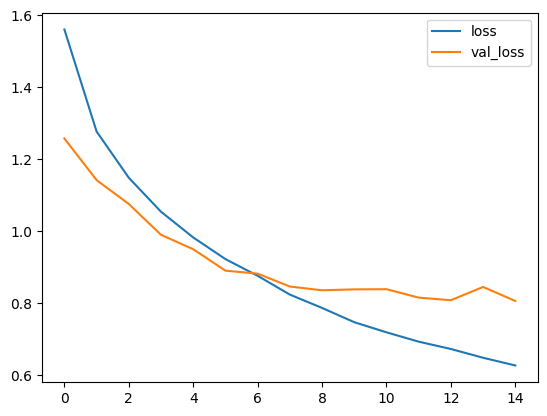

In [7]:
# taxas de loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

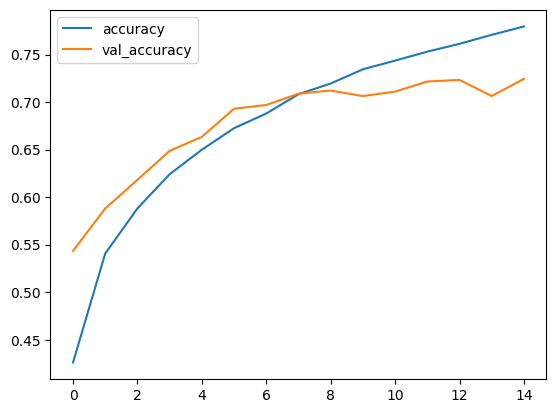

In [8]:
# acurácia
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Confusion matrix, without normalization
[[761  17  45  21  11   8  15  16  62  44]
 [  9 813   5   6   1   6   8   3  21 128]
 [ 55   6 596  43 103  72  85  18  10  12]
 [ 12   7  61 505  55 209  92  31   9  19]
 [ 24   2  57  65 652  39  72  77   9   3]
 [  7   3  60 141  58 637  45  35   7   7]
 [  5   5  23  40  33  28 852   7   4   3]
 [ 11   1  36  26  48  74  12 772   3  17]
 [ 54  32  14  10   8   9   9   4 819  41]
 [ 29  59  13  17   4  10   7   8  16 837]]


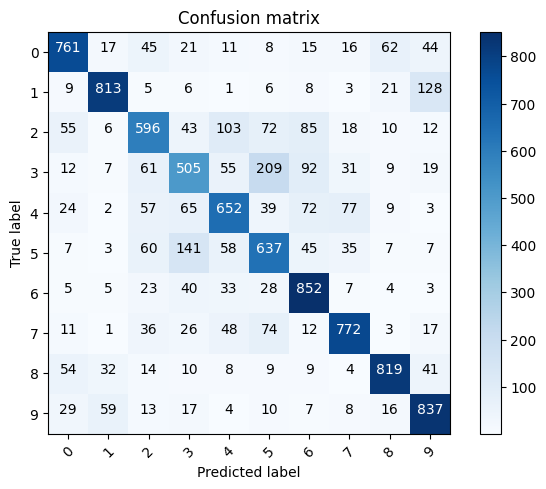

In [9]:
# matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))